# Notebook 06 - Hyperspectral Coastal Water Clustering

## Objective

This notebook uses the hyperspectral information from Planet Tanager to identify spectrally distinct classes within the main coastal-water body of Corozal, Belize using unsupervised machine learning.

## Planned analysis

1. Load the Tanager hyperspectral cube.
2. Load the cleaned main coastal-water mask.
3. Select reliable wavelengths.
4. Extract water-pixel spectra.
5. Reduce spectral dimensionality.
6. Apply unsupervised clustering.
7. Map the resulting spectral classes.
8. Compare cluster spectra and spatial distributions.

## Scientific interpretation

The resulting clusters represent spectral similarity classes, not directly measured water-quality categories.

Independent field observations would be required to assign physical water-quality meanings such as turbidity, suspended sediment, chlorophyll-a, or other environmental parameters.

In [2]:
#02_Imports

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\data\raw\20250824_171857_84_4001_ortho_sr_hdf5.h5")

WATER_MASK_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\outputs\maps\water_mask.npy")

OUTPUT_DIR = Path(r"C:\GIS_Work\5 GeoSpectra AI\outputs\notebook_06")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Environment ready.")

Environment ready.


In [3]:
#03_Load hyperspectral cube

with h5py.File(DATA_PATH, "r") as f:

    sr_dataset = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"]
    cube = sr_dataset[:]
    wavelengths = sr_dataset.attrs["wavelengths"]
    good_wavelengths = (sr_dataset.attrs["good_wavelengths"].astype(bool))
    cloud_mask = f["HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask"][:]
    cirrus_mask = f["HDFEOS/GRIDS/HYP/Data Fields/beta_cirrus_mask"][:]
    nodata_mask = f["HDFEOS/GRIDS/HYP/Data Fields/nodata_pixels"][:]

cube = cube.astype(np.float32)
cube[cube == -9999.0] = np.nan

print("Cube shape:", cube.shape)
print("Wavelengths:", len(wavelengths))
print("Good wavelengths:", np.sum(good_wavelengths))  

Cube shape: (426, 671, 763)
Wavelengths: 426
Good wavelengths: 368


In [4]:
#04_Load and clean water mask

from scipy import ndimage

water_mask = np.load(WATER_MASK_PATH)
labeled_water, num_features = ndimage.label(water_mask.astype(np.uint8))
component_sizes = np.bincount(labeled_water.ravel())
component_sizes[0] = 0
main_component = np.argmax(component_sizes)
main_water_mask = (labeled_water == main_component)

valid_water = (main_water_mask
               &(cloud_mask == 0)
               &(cirrus_mask == 0)
               &(nodata_mask == 0))

print("Original water pixels:", np.sum(water_mask))
print("Main water-body pixels:", np.sum(main_water_mask))
print("Valid analysis pixels:", np.sum(valid_water))

Original water pixels: 103239
Main water-body pixels: 94550
Valid analysis pixels: 94550


In [9]:
#05_Extract hyperspectral water spectra

# Rearrane cube from:
# (bands, rows, columns)
# to:
# (rows, columns, bands)

cube_pixels = np.moveaxis(cube, 0, -1)

# Extract only valid main-water pixels
water_spectra = cube_pixels[valid_water]

print("Hyperspectral water matrix")
print("="*60)

print("Number of water pixels:", water_spectra.shape[0])
print("Number of spectral bands:", water_spectra.shape[1])
print("Matrix shape            :", water_spectra.shape)

Hyperspectral water matrix
Number of water pixels: 94550
Number of spectral bands: 426
Matrix shape            : (94550, 426)


In [19]:
#06_Check spectral matrix quality

total_values = water_spectra.size
nan_count = np.isnan(water_spectra).sum()
inf_count = np.isinf(water_spectra).sum()
pixels_with_nan = np.isnan(water_spectra).any(axis=1).sum()
pixels_with_inf = np.isinf(water_spectra).any(axis=1).sum()

print(f"Total spectra values     :{total_values:,}")
print(f"NaN values               :{nan_count:,}")
print(f"Infinite values          :{inf_count:,}")
print(f"Pixels containing Nan values:{pixels_with_nan:,}")
print(f"Pixels containing Inf values:{pixels_with_inf:,}")

Total spectra values     :40,278,300
NaN values               :0
Infinite values          :0
Pixels containing Nan values:0
Pixels containing Inf values:0


In [25]:
#07_Select reliable wavelengths

reliable_wavelengths = wavelengths[good_wavelengths]
reliable_spectra = water_spectra[:, good_wavelengths]

print("Reliable Wavelengths Selection")
print("="*60)

print(f"Original spectral bands:{len(wavelengths)}")
print(f"Reliable spectral bands:{len(reliable_wavelengths)}")
print(f"Removed spectral bands:{len(wavelengths) - len(reliable_wavelengths)}")
print(f"New matrix shape      :{reliable_spectra.shape}")

Reliable Wavelengths Selection
Original spectral bands:426
Reliable spectral bands:368
Removed spectral bands:58
New matrix shape      :(94550, 368)


In [36]:
#08_Inspect reliable wavelength coverage

print("Reliable Spectral Coverage")
print("="*60)

print(f"First reliable wavelength: {reliable_wavelengths[0]:.2f} nm")
print(f"Last reliable wavelength: {reliable_wavelengths[-1]:.2f} nm")

# Find contiguous unreliable wavelength regions
bad_wavelengths = wavelengths[~good_wavelengths]

print(f"\nNumber of unreliable wavelengths: {len(bad_wavelengths)}")
print("\nUnreliable wavelengths ranges:")

bad_indices = np.where(~good_wavelengths)[0]

groups = np.split(bad_indices, np.where(np.diff(bad_indices) !=1)[0] + 1)

for group in groups:
    start_wavelength = wavelengths[group[0]]
    end_wavelength = wavelengths[group[-1]]

    print(f"Band{group[0]} - {group[-1]} : "f"{start_wavelength:.2f}-{end_wavelength:.2f}nm")

Reliable Spectral Coverage
First reliable wavelength: 376.44 nm
Last reliable wavelength: 2499.00 nm

Number of unreliable wavelengths: 58

Unreliable wavelengths ranges:
Band193 - 212 : 1342.41-1437.55nm
Band281 - 318 : 1782.58-1967.21nm


In [37]:
#09_Standardize reliable hyperspectral features

scaler = StandardScaler()

spectra_scaled = scaler.fit_transform(
    reliable_spectra
)

print("Feature Standardization")
print("=" * 60)

print("Input matrix shape :", reliable_spectra.shape)
print("Scaled matrix shape:", spectra_scaled.shape)

print("\nScaled data checks")
print(f"Overall mean : {np.mean(spectra_scaled):.6f}")
print(f"Overall std  : {np.std(spectra_scaled):.6f}")

Feature Standardization
Input matrix shape : (94550, 368)
Scaled matrix shape: (94550, 368)

Scaled data checks
Overall mean : 0.000000
Overall std  : 1.000000


In [38]:
#10_PCA dimensionality reduction

pca = PCA(
    n_components=20,
    random_state=42
)

pca_scores = pca.fit_transform(
    spectra_scaled
)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("PCA Results")
print("=" * 60)

print("Input features       :", spectra_scaled.shape[1])
print("Principal components :", pca_scores.shape[1])

print("\nVariance explained by each component:")
for i, variance in enumerate(explained_variance, start=1):
    print(
        f"PC{i:02d}: "
        f"{variance * 100:.2f}% "
        f"| Cumulative: {cumulative_variance[i-1] * 100:.2f}%"
    )

print(
    f"\nTotal variance explained by first 20 PCs: "
    f"{cumulative_variance[-1] * 100:.2f}%"
)

PCA Results
Input features       : 368
Principal components : 20

Variance explained by each component:
PC01: 80.49% | Cumulative: 80.49%
PC02: 9.55% | Cumulative: 90.04%
PC03: 4.78% | Cumulative: 94.81%
PC04: 0.98% | Cumulative: 95.79%
PC05: 0.59% | Cumulative: 96.38%
PC06: 0.56% | Cumulative: 96.93%
PC07: 0.30% | Cumulative: 97.24%
PC08: 0.26% | Cumulative: 97.50%
PC09: 0.23% | Cumulative: 97.73%
PC10: 0.21% | Cumulative: 97.94%
PC11: 0.18% | Cumulative: 98.12%
PC12: 0.15% | Cumulative: 98.27%
PC13: 0.14% | Cumulative: 98.41%
PC14: 0.13% | Cumulative: 98.54%
PC15: 0.12% | Cumulative: 98.66%
PC16: 0.10% | Cumulative: 98.76%
PC17: 0.09% | Cumulative: 98.84%
PC18: 0.08% | Cumulative: 98.93%
PC19: 0.07% | Cumulative: 99.00%
PC20: 0.07% | Cumulative: 99.07%

Total variance explained by first 20 PCs: 99.07%


In [39]:
#11_Select principal components for clustering

N_PCS = 6

clustering_features = pca_scores[:, :N_PCS]

variance_retained = cumulative_variance[N_PCS - 1] * 100

print("Clustering Feature Set")
print("=" * 60)

print(f"Selected principal components : {N_PCS}")
print(f"Variance retained             : {variance_retained:.2f}%")
print(f"Feature matrix shape          : {clustering_features.shape}")

Clustering Feature Set
Selected principal components : 6
Variance retained             : 96.93%
Feature matrix shape          : (94550, 6)


In [40]:
#12_Evaluate candidate cluster numbers

from sklearn.metrics import silhouette_score

K_VALUES = range(2, 9)

results = []

rng = np.random.default_rng(42)

sample_size = min(10000, len(clustering_features))

sample_indices = rng.choice(
    len(clustering_features),
    size=sample_size,
    replace=False
)

clustering_sample = clustering_features[sample_indices]

for k in K_VALUES:

    print(f"Testing K = {k}...")

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(clustering_features)

    sample_labels = labels[sample_indices]

    silhouette = silhouette_score(
        clustering_sample,
        sample_labels
    )

    results.append({
        "K": k,
        "Inertia": kmeans.inertia_,
        "Silhouette Score": silhouette
    })

results_df = pd.DataFrame(results)

print("\nCluster Evaluation Results")
print("=" * 60)

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

Testing K = 2...
Testing K = 3...
Testing K = 4...
Testing K = 5...
Testing K = 6...
Testing K = 7...
Testing K = 8...

Cluster Evaluation Results
 K       Inertia  Silhouette Score
 2 21996746.0000            0.3693
 3 14584355.0000            0.4022
 4 10072634.0000            0.4010
 5  8502697.0000            0.3314
 6  7467184.0000            0.3192
 7  6572355.0000            0.3412
 8  5989101.0000            0.3394


In [41]:
#13_Final K-means clustering

N_CLUSTERS = 3

final_kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=20
)

cluster_labels = final_kmeans.fit_predict(
    clustering_features
)

# Count pixels in each cluster
unique_clusters, cluster_counts = np.unique(
    cluster_labels,
    return_counts=True
)

print("Final K-means Clustering Results")
print("=" * 60)

print(f"Number of clusters: {N_CLUSTERS}")

print("\nPixels per spectral class:")

for cluster, count in zip(
    unique_clusters,
    cluster_counts
):
    percentage = (count / len(cluster_labels)) * 100

    print(
        f"Cluster {cluster + 1}: "
        f"{count:,} pixels "
        f"({percentage:.2f}%)"
    )

Final K-means Clustering Results
Number of clusters: 3

Pixels per spectral class:
Cluster 1: 60,549 pixels (64.04%)
Cluster 2: 32,650 pixels (34.53%)
Cluster 3: 1,351 pixels (1.43%)


In [42]:
#14_Create spatial cluster map

cluster_map = np.full(
    valid_water.shape,
    np.nan,
    dtype=np.float32
)

cluster_map[valid_water] = cluster_labels + 1

print("Spatial Cluster Map")
print("=" * 60)

print("Map shape:", cluster_map.shape)
print("Clustered pixels:", np.sum(np.isfinite(cluster_map)))
print(
    "Unique clusters:",
    np.unique(cluster_map[np.isfinite(cluster_map)])
)

Spatial Cluster Map
Map shape: (671, 763)
Clustered pixels: 94550
Unique clusters: [1. 2. 3.]


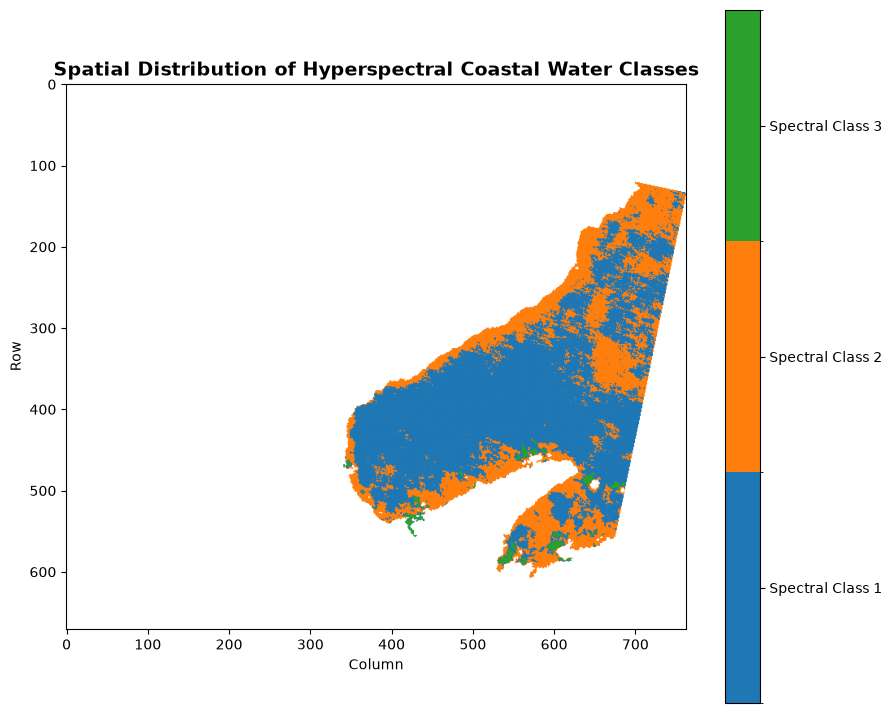

In [43]:
#15_Visualize spatial distribution of spectral classes

from matplotlib.colors import ListedColormap, BoundaryNorm

class_colors = ListedColormap([
    "tab:blue",
    "tab:orange",
    "tab:green"
])

class_bounds = [0.5, 1.5, 2.5, 3.5]

class_norm = BoundaryNorm(
    class_bounds,
    class_colors.N
)

fig, ax = plt.subplots(figsize=(10, 9))

im = ax.imshow(
    cluster_map,
    cmap=class_colors,
    norm=class_norm
)

ax.set_title(
    "Spatial Distribution of Hyperspectral Coastal Water Classes",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Column")
ax.set_ylabel("Row")

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=[1, 2, 3]
)

cbar.ax.set_yticklabels([
    "Spectral Class 1",
    "Spectral Class 2",
    "Spectral Class 3"
])

plt.show()